# Evaluierung & Benchmark: Faktenkonsistenz und Halluzinationserkennung

1. **SBERT Baseline (Bi-Encoder):**

2. **NLI Cross-Encoder:**  (Entailment / Contradiction)

3. **Klassischer NER-Overlap:** SpaCy  (Jaccard-Ähnlichkeit & Recall)

4. **Numerischer Slot-Check:** Reguläre Ausdrücke zur Erkennung nicht geerdeter Zahlen

### Untersuchte 4 Testklassen ( = 160$ feste Textpaare aus ):


In [1]:
import os
import sys
import glob
import json
import re
import random
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import display
import torch

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Arbeitsverzeichnis:', os.getcwd())
print(f'Nutze Device: {DEVICE}')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150
})


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis
Nutze Device: mps


## 1. Evaluationsdaten laden


In [2]:
CSV_PATH = os.path.join(REPO_ROOT, 'results/evaluation/factual_consistency_metric_results.csv')

df_res = pd.read_csv(CSV_PATH)
print(f'Ergebnisse geladen: {len(df_res)} Textpaare aus {CSV_PATH}')
print('Verteilung der Testklassen:')
for cat, cnt in df_res['category'].value_counts().items():
    print(f'  - {cat}: {cnt}')

display(df_res.head(3))


Ergebnisse geladen: 160 Textpaare aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/factual_consistency_metric_results.csv
Verteilung der Testklassen:
  - 1_Gold_Positives: 50
  - 2_Real_Model_Hallucinations: 50
  - 3_Random_Shuffle_Negatives: 30
  - 4_Targeted_Minimal_Perturbations: 30


,id,category,subtype,as_text,ls_text,is_factually_correct,description,sbert_raw,sbert_score,nli_p_entail,nli_p_neutral,nli_p_contra,nli_factuality,ner_jaccard,ner_recall,number_consistency,composite_factuality
0,gold_lh_001,1_Gold_Positives,Lebenshilfe_Practice_Reference,"Kiel, 15.10.2020. Arbeit zweiter oder dritter ...",Positionspapier: Bildung und Teilhabe am Arbei...,1,Menschlich geprüfte Referenz der Lebenshilfe,0.518583,0.759292,0.090745,0.749759,0.159496,0.465625,0.032258,0.047619,0.333333,0.117848
1,gold_lh_002,1_Gold_Positives,Lebenshilfe_Practice_Reference,„Kieler Sicherheitskonzept Sexualstraftäter“ (...,Infos zum Kieler Sicherheitskonzept Sexualstra...,1,Menschlich geprüfte Referenz der Lebenshilfe,0.864778,0.932389,0.212591,0.587062,0.200346,0.506122,0.076923,0.166667,1.000000,0.471903
2,gold_lh_003,1_Gold_Positives,Lebenshilfe_Practice_Reference,"Zielgruppe: Menschen, die auf der Suche nach W...",Fischbeker Reethen. In Hamburg entsteht ein ne...,1,Menschlich geprüfte Referenz der Lebenshilfe,0.876665,0.938332,0.138740,0.396457,0.464804,0.336968,0.160000,0.216216,0.000000,0.000000


## 2. Quantitative Vergleichstabelle nach Testklasse


In [3]:
metrics_cols ={
"sbert_score":"SBERT Similarity (R_sem)",
"nli_factuality":"NLI Factuality Score",
"nli_p_contra":"NLI P(Contradiction)",
"ner_jaccard":"NER Jaccard Overlap",
"number_consistency":"Number Consistency Check",
"composite_factuality":"Composite Multiplicative Score"
}

df_summary =df_res .groupby ("category")[list (metrics_cols .keys ())].mean ().rename (columns =metrics_cols )
df_std =df_res .groupby ("category")[list (metrics_cols .keys ())].std ().rename (columns =metrics_cols )

formatted_rows =[]
for cat in df_summary .index :
    row ={"Testklasse":cat }
    for col in df_summary .columns :
        row [col ]=f"{df_summary .loc [cat ,col ]:.4f} ± {df_std .loc [cat ,col ]:.4f}"
    formatted_rows .append (row )

df_table =pd .DataFrame (formatted_rows )
try :
    display (df_table )
except Exception :
    print (df_table .to_string (index =False ))


,Testklasse,SBERT Similarity (R_sem),NLI Factuality Score,NLI P(Contradiction),NER Jaccard Overlap,Number Consistency Check,Composite Multiplicative Score
0,1_Gold_Positives,0.9161 ± 0.0487,0.4854 ± 0.1048,0.2349 ± 0.1316,0.1549 ± 0.1760,0.6824 ± 0.3280,0.3015 ± 0.1560
1,2_Real_Model_Hallucinations,0.9035 ± 0.0431,0.4638 ± 0.0463,0.2041 ± 0.1120,0.1653 ± 0.1708,0.9200 ± 0.2252,0.3873 ± 0.1061
2,3_Random_Shuffle_Negatives,0.5560 ± 0.0570,0.4796 ± 0.1442,0.2891 ± 0.1553,0.0008 ± 0.0041,0.2918 ± 0.4109,0.0775 ± 0.1211
3,4_Targeted_Minimal_Perturbations,0.8121 ± 0.0844,0.4027 ± 0.1911,0.4091 ± 0.3084,0.6778 ± 0.4484,0.8167 ± 0.3824,0.2927 ± 0.1825


## 3. Verteilungsanalyse (4-Panel Boxplots)


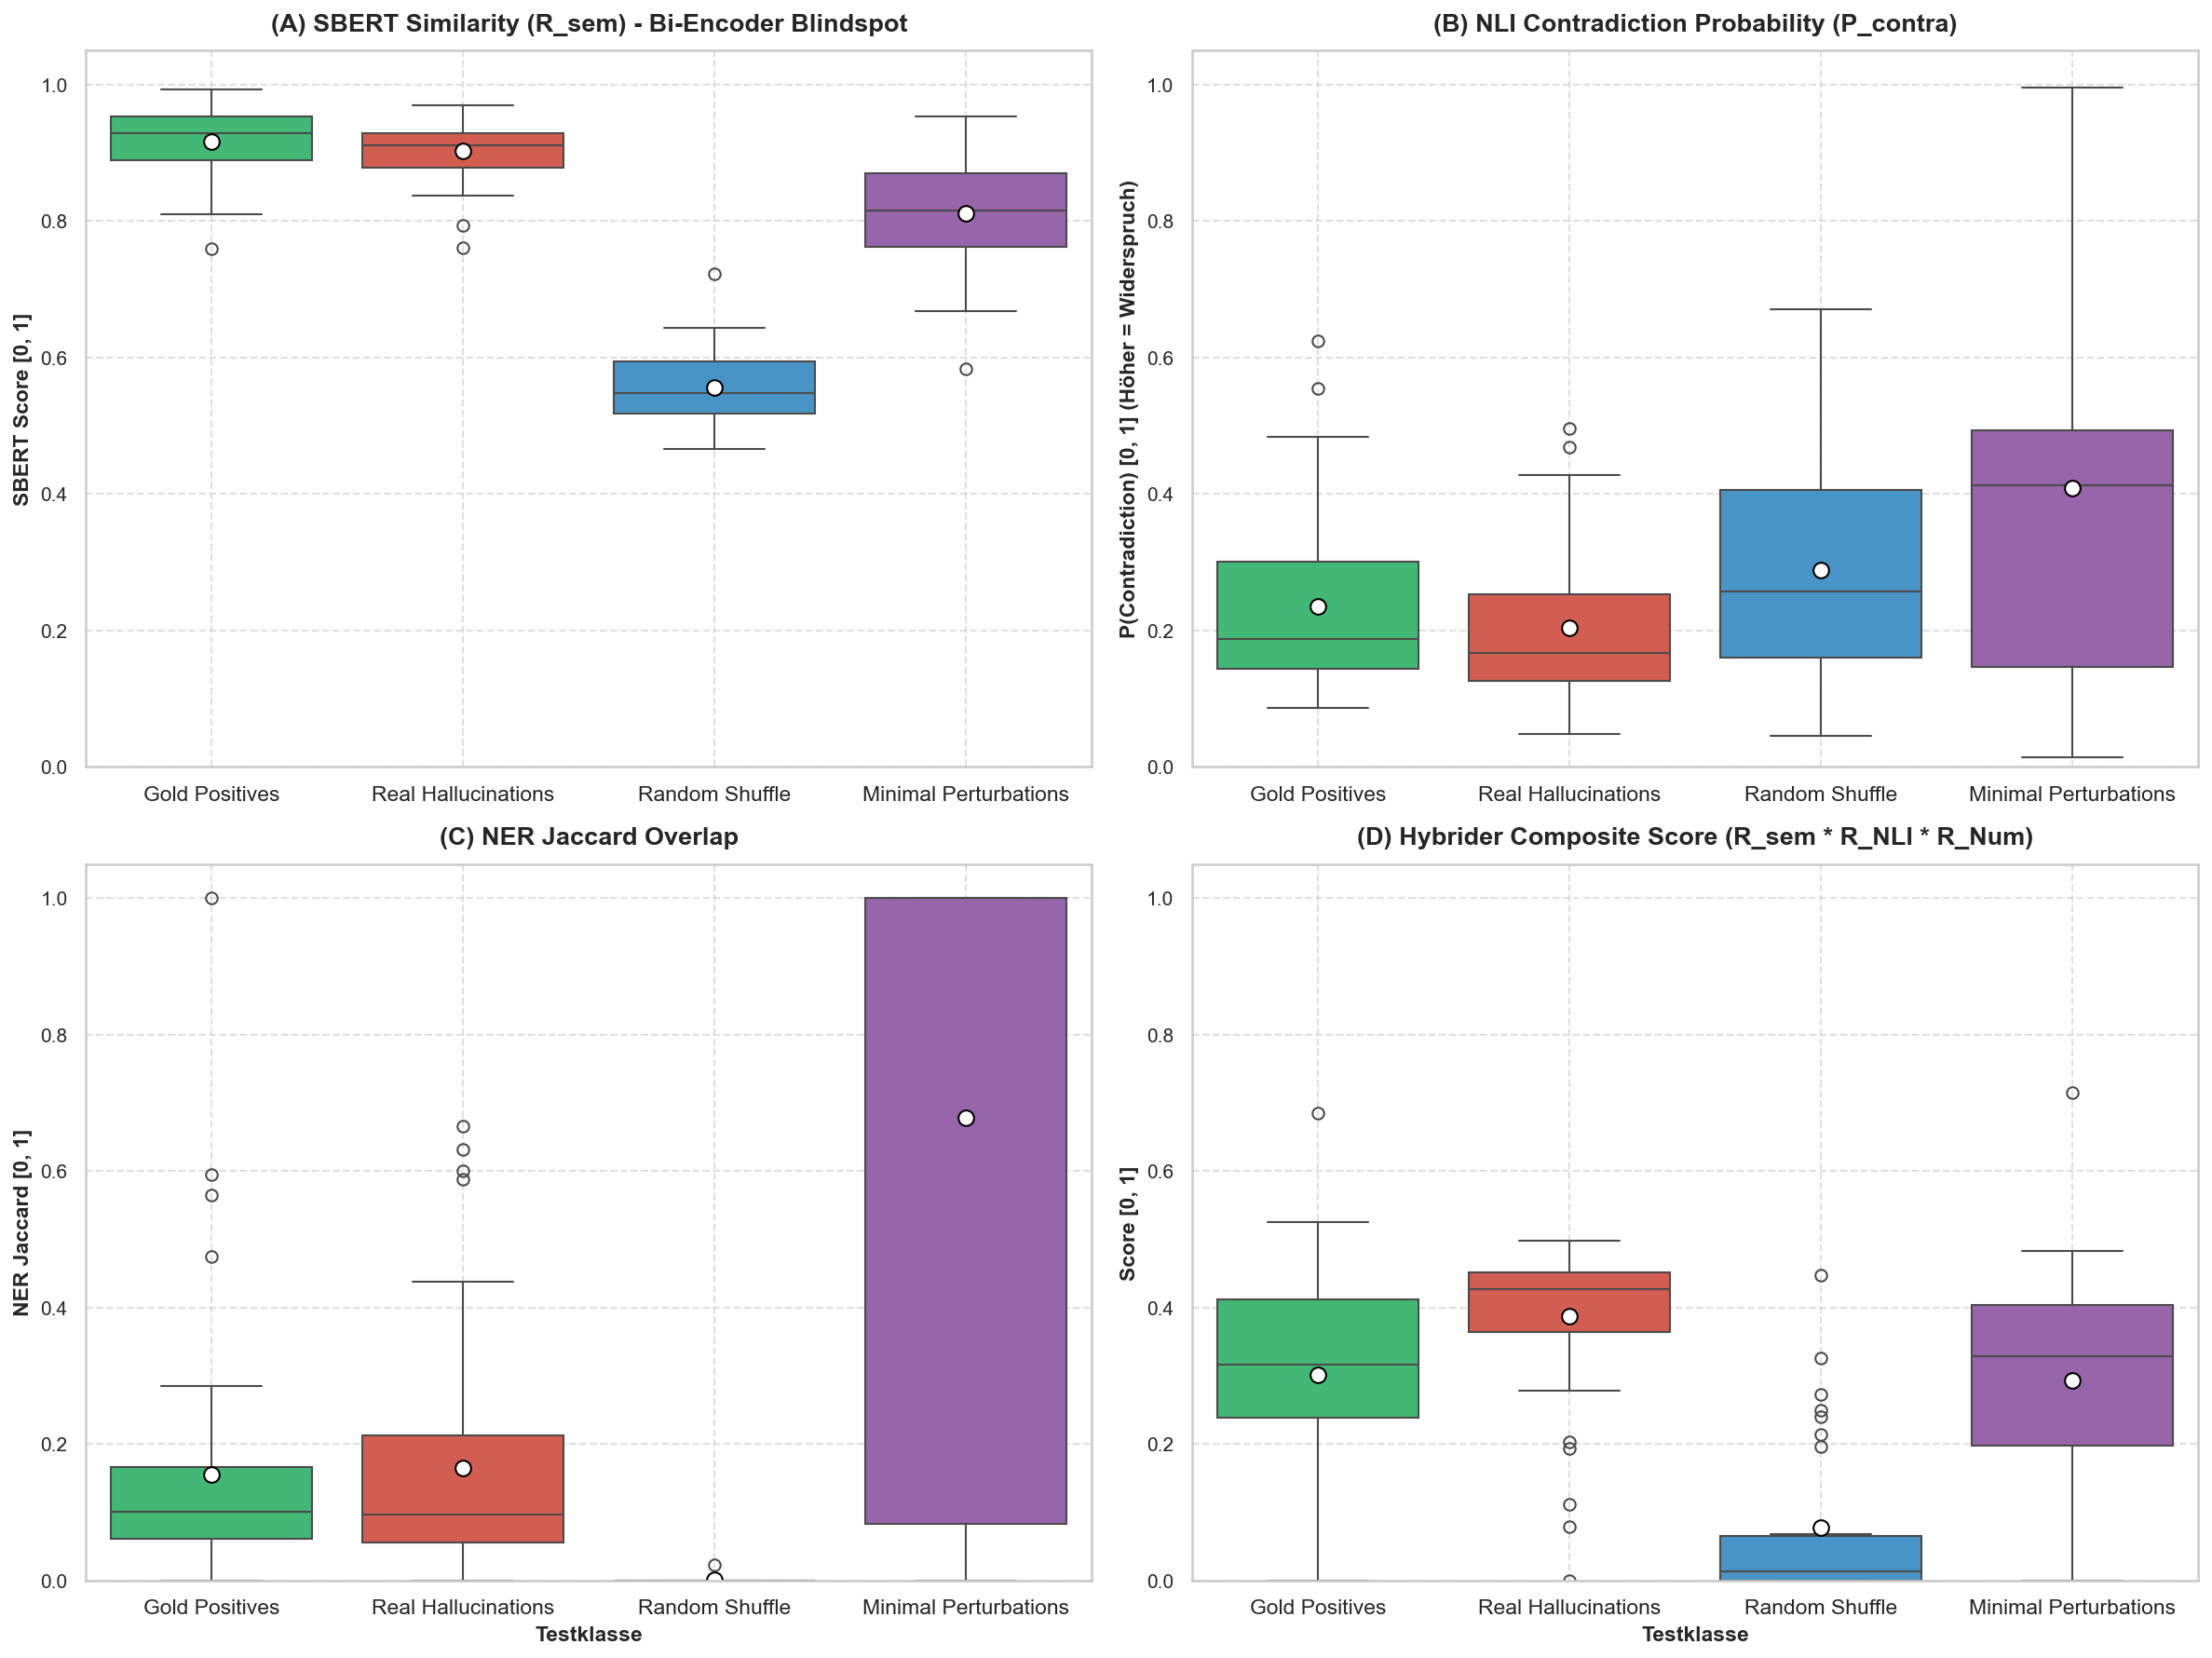

Plot gespeichert unter: research/img/analysis/factuality_metrics_4panel_comparison.png


In [4]:
cat_map = {
    "1_Gold_Positives": "Gold Positives",
    "2_Real_Model_Hallucinations": "Real Hallucinations",
    "3_Random_Shuffle_Negatives": "Random Shuffle",
    "4_Targeted_Minimal_Perturbations": "Minimal Perturbations"
}
df_res["category_display"] = df_res["category"].map(lambda c: cat_map.get(c, c))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = {
    "Gold Positives": "#2ecc71",
    "Real Hallucinations": "#e74c3c",
    "Random Shuffle": "#3498db",
    "Minimal Perturbations": "#9b59b6"
}

# SBERT Similarity
sns.boxplot(ax=axes[0, 0], data=df_res, x="category_display", y="sbert_score", hue="category_display", palette=palette, legend=False, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8})
axes[0, 0].set_title("(A) SBERT Similarity (R_sem) - Bi-Encoder Blindspot", fontsize=13, fontweight="bold", pad=10)
axes[0, 0].set_ylabel("SBERT Score [0, 1]", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("")

# NLI P(Contradiction)
sns.boxplot(ax=axes[0, 1], data=df_res, x="category_display", y="nli_p_contra", hue="category_display", palette=palette, legend=False, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8})
axes[0, 1].set_title("(B) NLI Contradiction Probability (P_contra)", fontsize=13, fontweight="bold", pad=10)
axes[0, 1].set_ylabel("P(Contradiction) [0, 1] (Höher = Widerspruch)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("")

# NER Jaccard Overlap
sns.boxplot(ax=axes[1, 0], data=df_res, x="category_display", y="ner_jaccard", hue="category_display", palette=palette, legend=False, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8})
axes[1, 0].set_title("(C) NER Jaccard Overlap", fontsize=13, fontweight="bold", pad=10)
axes[1, 0].set_ylabel("NER Jaccard [0, 1]", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Testklasse", fontsize=11, fontweight="bold")

# Composite Multiplicative Score
sns.boxplot(ax=axes[1, 1], data=df_res, x="category_display", y="composite_factuality", hue="category_display", palette=palette, legend=False, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8})
axes[1, 1].set_title("(D) Hybrider Composite Score (R_sem * R_NLI * R_Num)", fontsize=13, fontweight="bold", pad=10)
axes[1, 1].set_ylabel("Score [0, 1]", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Testklasse", fontsize=11, fontweight="bold")

# Einheitliche Y-Skala von 0 bis 1 auf allen 4 Subplots
for ax in axes.flat:
    ax.set_ylim(0.0, 1.05)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out = "research/img/analysis/factuality_metrics_4panel_comparison.png"
os.makedirs(os.path.dirname(plot_out), exist_ok=True)
plt.savefig(plot_out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot gespeichert unter: {plot_out}")


## 4. ROC-Kurven & Trennkraft-Analyse


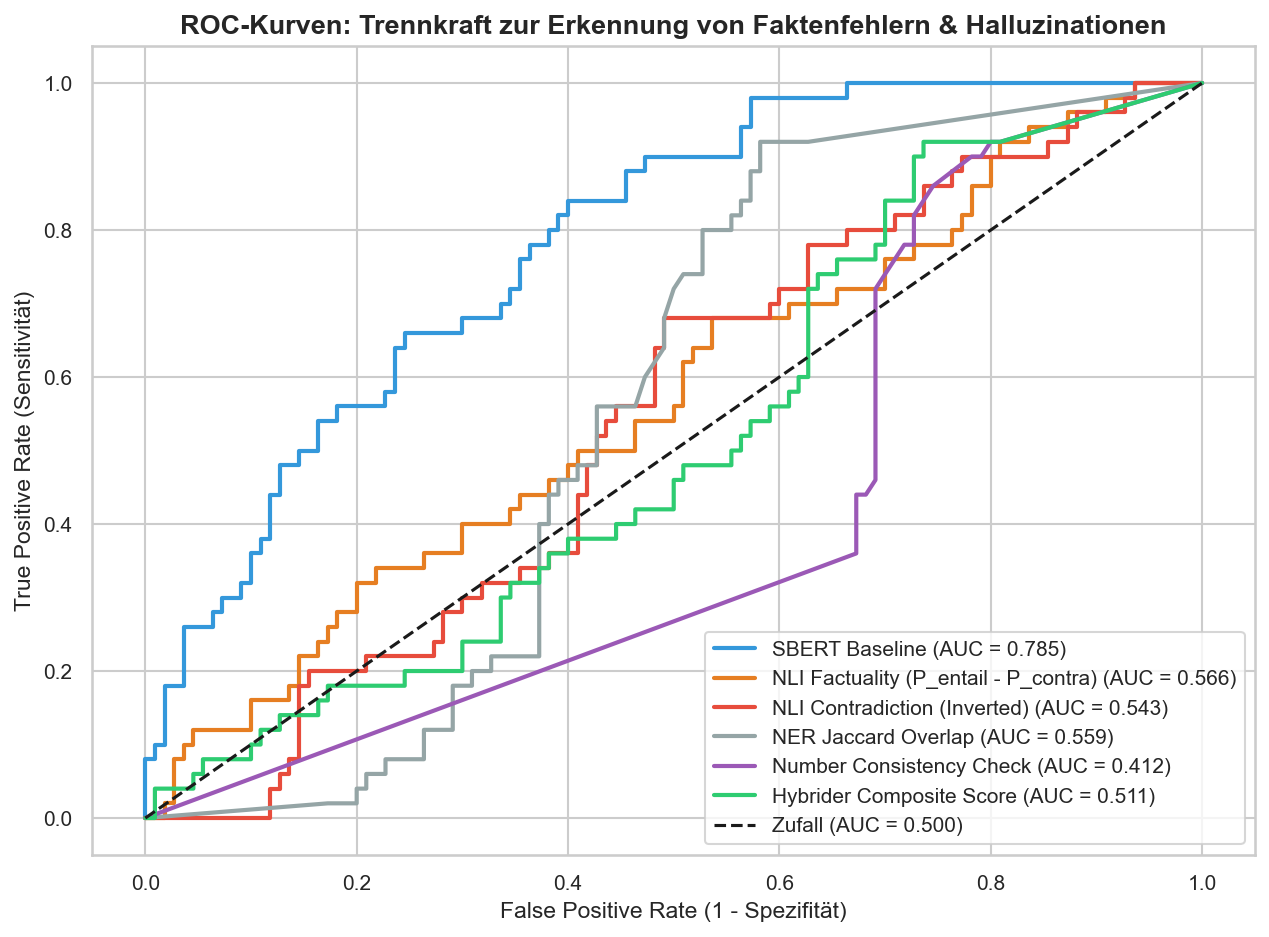

ROC Plot gespeichert unter: research/img/analysis/factuality_metrics_roc_curves.png


In [5]:
plt .figure (figsize =(10 ,7 ))
y_true =df_res ["is_factually_correct"].values 

eval_configs =[
("SBERT Baseline",df_res ["sbert_score"].values ,"#3498db"),
("NLI Factuality (P_entail - P_contra)",df_res ["nli_factuality"].values ,"#e67e22"),
("NLI Contradiction (Inverted)",1.0 -df_res ["nli_p_contra"].values ,"#e74c3c"),
("NER Jaccard Overlap",df_res ["ner_jaccard"].values ,"#95a5a6"),
("Number Consistency Check",df_res ["number_consistency"].values ,"#9b59b6"),
("Hybrider Composite Score",df_res ["composite_factuality"].values ,"#2ecc71"),
]

for name ,scores ,color in eval_configs :
    auc =roc_auc_score (y_true ,scores )
    fpr ,tpr ,_ =roc_curve (y_true ,scores )
    plt .plot (fpr ,tpr ,label =f"{name } (AUC = {auc :.3f})",color =color ,lw =2 )

plt .plot ([0 ,1 ],[0 ,1 ],"k--",lw =1.5 ,label ="Zufall (AUC = 0.500)")
plt .xlabel ("False Positive Rate (1 - Spezifität)",fontsize =11 )
plt .ylabel ("True Positive Rate (Sensitivität)",fontsize =11 )
plt .title ("ROC-Kurven: Trennkraft zur Erkennung von Faktenfehlern & Halluzinationen",fontsize =13 ,fontweight ="bold")
plt .legend (loc ="lower right",fontsize =10 )

roc_out ="research/img/analysis/factuality_metrics_roc_curves.png"
plt .savefig (roc_out ,dpi =300 ,bbox_inches ="tight")
plt .show ()
print (f"ROC Plot gespeichert unter: {roc_out }")


## 5. Qualitative Fallstudien (Modell-Halluzinationen & Perturbationen)


In [6]:
case_studies =df_res [df_res ["category"].isin (["2_Real_Model_Hallucinations","4_Targeted_Minimal_Perturbations"])].head (6 )

print ("="*95 )
print ("DETAIL-INSPEKTION: WIE REAGIEREN DIE METRIKEN AUF KONKRETE FEHLER?")
print ("="*95 )

for idx ,row in case_studies .iterrows ():
    print (f"\n[FALL {idx +1 }] Subtyp: {row ['subtype']} | Klasse: {row ['category']}")
    print (f"AS-QUELLE: {row ['as_text'][:120 ]}...")
    print (f"LS-ZIEL:   {row ['ls_text'][:120 ]}...")
    print (f"-> SBERT Score:        {row ['sbert_score']:.3f} (Täuschend hoch? {'JA'if row ['sbert_score']>0.80 else 'NEIN'})")
    print (f"-> NLI P(Contra):      {row ['nli_p_contra']:.3f} (Widerspruch erkannt? {'JA'if row ['nli_p_contra']>0.35 else 'NEIN'})")
    print (f"-> NER Jaccard:        {row ['ner_jaccard']:.3f}")
    print (f"-> Number Consistency: {row ['number_consistency']:.3f}")
    print (f"-> Composite Score:    {row ['composite_factuality']:.3f}")
    print ("-"*95 )


DETAIL-INSPEKTION: WIE REAGIEREN DIE METRIKEN AUF KONKRETE FEHLER?

[FALL 51] Subtyp: mBART_SFT_DPO_hannover | Klasse: 2_Real_Model_Hallucinations
AS-QUELLE: Neu als Chipkarte Fragen und Antworten zum Deutschland­ticket Kundinnen und Kunden können das Deutschlandticket online b...
LS-ZIEL:   Was ist das Deutschland-Ticket? Wie bekomme ich eine Chip-Karte? Welche Informationen brauche ich, damit ich meine Fahrk...
-> SBERT Score:        0.913 (Täuschend hoch? JA)
-> NLI P(Contra):      0.085 (Widerspruch erkannt? NEIN)
-> NER Jaccard:        0.108
-> Number Consistency: 1.000
-> Composite Score:    0.466
-----------------------------------------------------------------------------------------------

[FALL 52] Subtyp: mBART_SFT_DPO_brandeins | Klasse: 2_Real_Model_Hallucinations
AS-QUELLE: Das Gymnasium vermittelt bis zum Abitur eine Vielzahl fachlicher und überfachlicher Kompetenzen. Neben der Persönlichkei...
LS-ZIEL:   Das Gymnasium vermittelt bis zum Abitur eine Vielzahl fachlicher u